<a href="https://colab.research.google.com/github/pranshulab/Data_science_journey/blob/main/Projects/Experiment_3_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [53]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "mrsimple07/student-exam-performance-prediction"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-exam-performance-prediction' dataset.
Path to dataset files: /kaggle/input/student-exam-performance-prediction


In [54]:
import os

print(os.listdir(path))

['student_exam_data_new.csv', 'student_exam_data.csv']


In [55]:
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]

print("CSV files:", csv_files)

CSV files: ['student_exam_data_new.csv', 'student_exam_data.csv']


In [56]:
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

print(df.head())

   Study Hours  Previous Exam Score  Pass/Fail
0     4.370861            81.889703          0
1     9.556429            72.165782          1
2     7.587945            58.571657          0
3     6.387926            88.827701          1
4     2.404168            81.083870          0


In [57]:
print(df.shape)
print(df.columns)

(500, 3)
Index(['Study Hours', 'Previous Exam Score', 'Pass/Fail'], dtype='object')


In [58]:
print(df.head(10))

   Study Hours  Previous Exam Score  Pass/Fail
0     4.370861            81.889703          0
1     9.556429            72.165782          1
2     7.587945            58.571657          0
3     6.387926            88.827701          1
4     2.404168            81.083870          0
5     2.403951            49.757016          0
6     1.522753            94.655631          0
7     8.795585            89.352235          1
8     6.410035            96.987995          1
9     7.372653            83.543171          1


In [59]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
None


In [60]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


In [61]:
df.isnull().sum()

,0
Study Hours,0
Previous Exam Score,0
Pass/Fail,0


In [62]:
df['Pass/Fail'].value_counts()

,count
Pass/Fail,
0,316
1,184


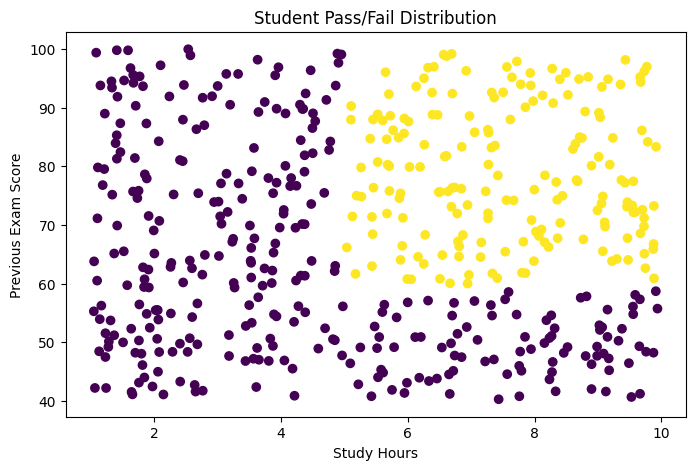

In [63]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study Hours"],
    df["Previous Exam Score"],
    c=df["Pass/Fail"]
)

plt.xlabel("Study Hours")
plt.ylabel("Previous Exam Score")
plt.title("Student Pass/Fail Distribution")

plt.show()

In [64]:
X = df[['Study Hours', 'Previous Exam Score']]
y = df['Pass/Fail']

In [65]:
X.head()

,Study Hours,Previous Exam Score
0,4.370861,81.889703
1,9.556429,72.165782
2,7.587945,58.571657
3,6.387926,88.827701
4,2.404168,81.083870


In [66]:
y.head()

,Pass/Fail
0,0
1,1
2,0
3,1
4,0


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [68]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [69]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [71]:
fit_transform()

NameError: name 'fit_transform' is not defined

In [72]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y):

        # Initialize weights and bias
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        # Training
        for epoch in range(self.epochs):

            for i in range(len(X)):

                # Calculate weighted sum
                linear_output = np.dot(X[i], self.weights) + self.bias

                # Step activation function
                prediction = 1 if linear_output >= 0 else 0

                # Calculate error
                error = y.iloc[i] - prediction

                # Update weights
                self.weights += self.learning_rate * error * X[i]

                # Update bias
                self.bias += self.learning_rate * error

        return self

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        predictions = np.where(linear_output >= 0, 1, 0)

        return predictions

In [73]:
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=100
)

perceptron.fit(
    X_train_scaled,
    y_train
)

In [74]:
y_pred_perceptron = perceptron.predict(X_test_scaled)

In [75]:
perceptron_accuracy = accuracy_score(
    y_test,
    y_pred_perceptron
)

print(
    "Perceptron Accuracy:",
    perceptron_accuracy
)

Perceptron Accuracy: 0.79


In [76]:
cm = confusion_matrix(
    y_test,
    y_pred_perceptron
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[46 17]
 [ 4 33]]


In [77]:
print(
    classification_report(
        y_test,
        y_pred_perceptron
    )
)


              precision    recall  f1-score   support

           0       0.92      0.73      0.81        63
           1       0.66      0.89      0.76        37

    accuracy                           0.79       100
   macro avg       0.79      0.81      0.79       100
weighted avg       0.82      0.79      0.79       100



**Implement the MLP using Keras**

In [78]:
model = Sequential([

    Dense(
        8,
        activation="relu",
        input_shape=(2,)
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
Dense(8, activation="relu")

<Dense name=dense_2, built=False>

In [80]:
Dense(1, activation="sigmoid")

<Dense name=dense_3, built=False>

In [81]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [82]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.2344 - loss: 0.7318 - val_accuracy: 0.2875 - val_loss: 0.7116
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4250 - loss: 0.7025 - val_accuracy: 0.5250 - val_loss: 0.6802
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5156 - loss: 0.6764 - val_accuracy: 0.5500 - val_loss: 0.6538
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5688 - loss: 0.6543 - val_accuracy: 0.6000 - val_loss: 0.6288
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5844 - loss: 0.6336 - val_accuracy: 0.6125 - val_loss: 0.6077
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5969 - loss: 0.6155 - val_accuracy: 0.6375 - val_loss: 0.5885
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6062 - loss: 0.5984 - val_accuracy: 0.6375 - val_loss: 0.5702
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6156 - loss: 0.5820 - val_accuracy: 0.6750 - val_

In [83]:
mlp_loss, mlp_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("MLP Accuracy:", mlp_accuracy)

MLP Accuracy: 0.9399999976158142


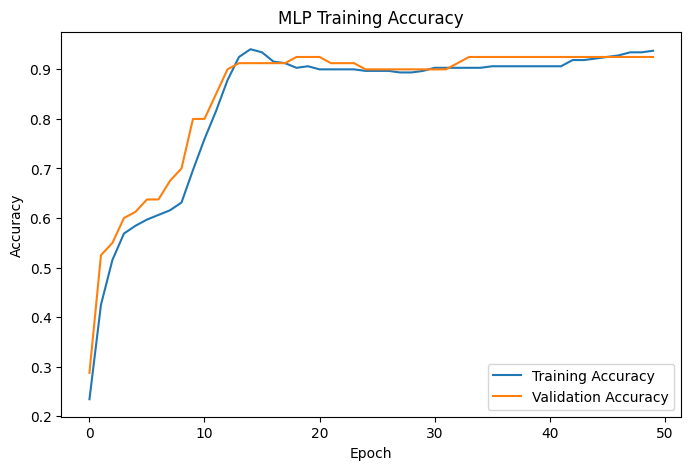

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("MLP Training Accuracy")

plt.legend()

plt.show()

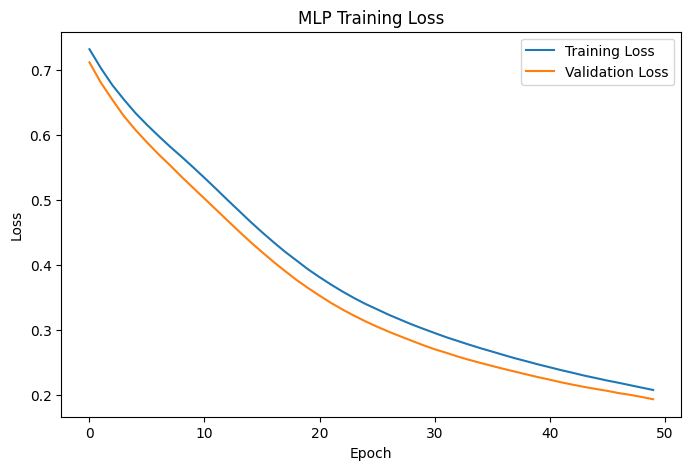

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("MLP Training Loss")

plt.legend()

plt.show()

In [86]:
new_students = pd.DataFrame({
    "Study Hours": [2, 5, 7],
    "Previous Exam Score": [40, 70, 80]
})

print(new_students)

   Study Hours  Previous Exam Score
0            2                   40
1            5                   70
2            7                   80


In [87]:
new_students_scaled = scaler.transform(new_students)

In [88]:
perceptron_predictions = perceptron.predict(
    new_students_scaled
)

print("Perceptron Predictions:")

for i, prediction in enumerate(perceptron_predictions):

    result = "Pass" if prediction == 1 else "Fail"

    print(
        f"Student {i+1}: {result}"
    )

Perceptron Predictions:
Student 1: Fail
Student 2: Fail
Student 3: Pass


In [89]:
mlp_probabilities = model.predict(
    new_students_scaled
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [90]:
mlp_predictions = (
    mlp_probabilities >= 0.5
).astype(int).flatten()

In [91]:
print("MLP Predictions:")

for i, prediction in enumerate(mlp_predictions):

    result = "Pass" if prediction == 1 else "Fail"

    print(
        f"Student {i+1}: {result}"
    )

MLP Predictions:
Student 1: Fail
Student 2: Fail
Student 3: Pass


In [92]:
comparison = pd.DataFrame({

    "Study Hours": new_students["Study Hours"],

    "Previous Exam Score":
        new_students["Previous Exam Score"],

    "Perceptron":
        [
            "Pass" if x == 1 else "Fail"
            for x in perceptron_predictions
        ],

    "MLP":
        [
            "Pass" if x == 1 else "Fail"
            for x in mlp_predictions
        ]
})

print(comparison)

   Study Hours  Previous Exam Score Perceptron   MLP
0            2                   40       Fail  Fail
1            5                   70       Fail  Fail
2            7                   80       Pass  Pass


In [93]:
print("================================")
print("MODEL COMPARISON")
print("================================")

print(
    f"Perceptron Accuracy: {perceptron_accuracy:.4f}"
)

print(
    f"MLP Accuracy: {mlp_accuracy:.4f}"
)

MODEL COMPARISON
Perceptron Accuracy: 0.7900
MLP Accuracy: 0.9400


In [94]:
results = pd.DataFrame({
    "Model": [
        "Perceptron",
        "MLP"
    ],

    "Accuracy": [
        perceptron_accuracy,
        mlp_accuracy
    ]
})

print(results)

        Model  Accuracy
0  Perceptron      0.79
1         MLP      0.94
